<a href="https://colab.research.google.com/github/nashwaparvis/DBA-NorthStar-Coursework/blob/main/notebooks/02_R_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
system("git clone https://github.com/nashwaparvis/DBA-NorthStar-Coursework.git")

In [2]:
list.files()

[1] "DBA-NorthStar-Coursework" "sample_data"

In [3]:
install.packages("readr")
install.packages("ggplot2")
install.packages("dplyr")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [4]:
library(readr)
library(ggplot2)
library(dplyr)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [5]:
drivers <- read_csv("DBA-NorthStar-Coursework/dataset/drivers.csv")
vehicles <- read_csv("DBA-NorthStar-Coursework/dataset/vehicles.csv")
hubs <- read_csv("DBA-NorthStar-Coursework/dataset/hubs.csv")
incidents <- read_csv("DBA-NorthStar-Coursework/dataset/incidents.csv")
customers <- read_csv("DBA-NorthStar-Coursework/dataset/customers.csv")
app_events <- read_csv("DBA-NorthStar-Coursework/dataset/app_events.csv")
orders <- read_csv("DBA-NorthStar-Coursework/dataset/orders.csv")
deliveries <- read_csv("DBA-NorthStar-Coursework/dataset/deliveries.csv")
complaints <- read_csv("DBA-NorthStar-Coursework/dataset/complaints.csv")

Rows: 170 Columns: 8
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (4): driver_id, base_zone, employment_type, shift_preference
dbl (4): years_experience, training_score, driver_rating, active_flag

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 120 Columns: 8
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (5): vehicle_id, vehicle_type, assigned_zone, maintenance_status, telem...
dbl  (2): battery_health_pct, odometer_km
dttm (1): commission_date

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 8 Columns: 5
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (4): hub_id, hub_name, zone, hub_type
dbl (1): capacit

In [6]:
head(deliveries)

delivery_id,order_id,driver_id,vehicle_id,hub_id,dispatch_time,delivery_completed_at,delivery_status,route_distance_km,manual_route_override_count,proof_of_completion_missing,customer_rating_post_delivery,fuel_or_charge_cost
<chr>,<chr>,<chr>,<chr>,<chr>,<dttm>,<dttm>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
DL00001,O00938,D004,V056,H05,2024-06-18 10:57:00,2024-06-19 09:05:59,Failed,17.26,1,0,3.07,12.05
DL00002,O00004,D138,V007,H02,2025-01-11 18:45:00,2025-01-11 17:39:00,OnTime,10.34,1,0,5.00,13.41
DL00003,O00639,D006,V049,H02,2025-06-02 20:39:00,2025-06-02 21:45:32,OnTime,7.92,0,0,4.98,8.51
DL00004,O00313,D116,V055,H02,2024-03-08 23:31:00,2024-03-09 23:30:08,Delayed,16.42,0,0,4.18,13.62
DL00005,O00844,D108,V034,H01,2025-09-21 11:43:00,2025-09-21 15:45:34,OnTime,14.52,1,0,4.18,9.22
DL00006,O00029,D037,V098,H03,2024-09-11 12:40:00,2024-09-12 17:11:52,Delayed,13.84,0,0,1.57,9.58


In [7]:
head(complaints)

complaint_id,customer_id,order_id,complaint_type,channel,severity,created_at,status,resolution_days,compensation_amount
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dttm>,<chr>,<dbl>,<dbl>
CP0001,C0464,O00814,AppIssue,App,High,2025-03-30 02:36:00,Open,11,23.99
CP0002,C0056,O00628,MissedPickup,Phone,Medium,2024-11-07 10:05:00,Open,4,21.64
CP0003,C0469,O00384,Delay,Chatbot,High,2024-01-02 15:47:00,Open,16,26.41
CP0004,C0631,O00406,Delay,App,Medium,2025-01-14 13:07:00,AwaitingCustomer,7,23.44
CP0005,C0535,O00154,Delay,Email,Medium,2024-08-31 05:56:00,Resolved,1,16.18
CP0006,C0096,O00147,Delay,App,Medium,2024-07-22 07:43:00,Resolved,9,18.51


In [8]:
head(vehicles)

vehicle_id,vehicle_type,assigned_zone,commission_date,battery_health_pct,odometer_km,maintenance_status,telematics_version
<chr>,<chr>,<chr>,<dttm>,<dbl>,<dbl>,<chr>,<chr>
V001,EV,North,2024-12-28 23:48:00,71.8,56928,Active,v2.2
V002,EV,AIRPORT,2024-04-21 16:14:00,67.9,159368,InRepair,v2.2
V003,CargoVan,north,2025-11-24 23:59:00,91.7,219359,Active,v2.1
V004,Hybrid,RiverSide,2024-06-07 13:21:00,NA,36310,Active,v2.2
V005,CargoVan,West,2025-11-15 11:08:00,58.6,146638,Active,v2.2
V006,EV,Central,2025-11-22 06:39:00,78.6,141381,Active,v2.1


In [9]:
summary(deliveries$manual_route_override_count)
summary(deliveries$customer_rating_post_delivery)
summary(complaints$resolution_days)
summary(vehicles$battery_health_pct)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 0.0000  0.0000  1.0000  0.9695  2.0000  7.0000 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max.     NAs 
  1.000   3.360   4.040   3.865   4.550   5.000      14 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  1.000   3.750   7.000   7.928  11.000  25.000 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max.     NAs 
  42.00   68.20   78.05   76.79   85.78  100.00       4 

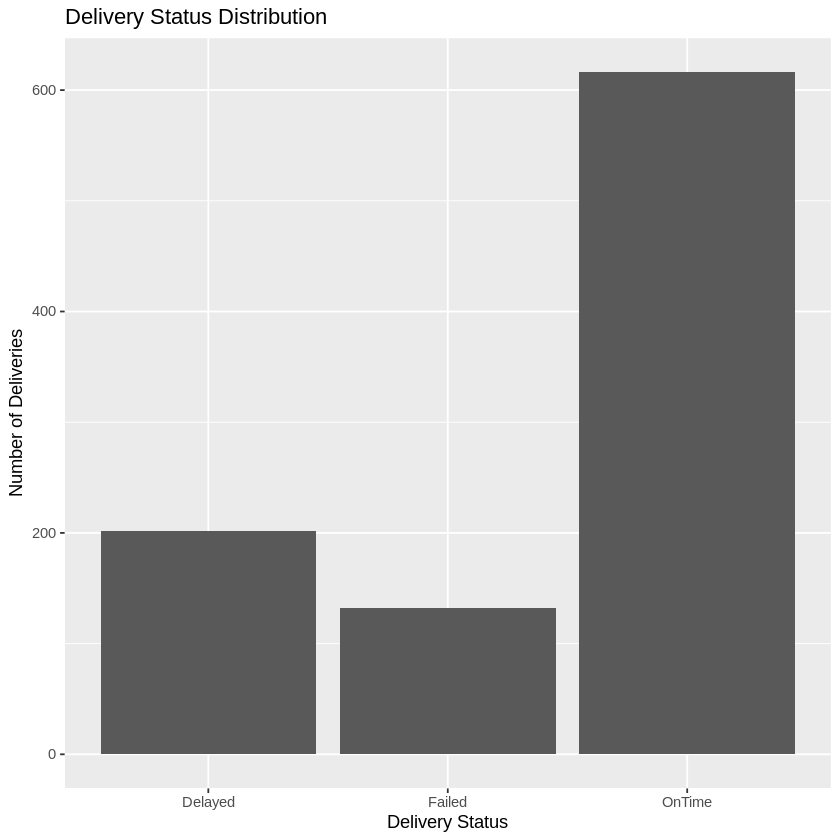

In [10]:
ggplot(deliveries, aes(x = delivery_status)) +
  geom_bar() +
  labs(
    title = "Delivery Status Distribution",
    x = "Delivery Status",
    y = "Number of Deliveries"
  )

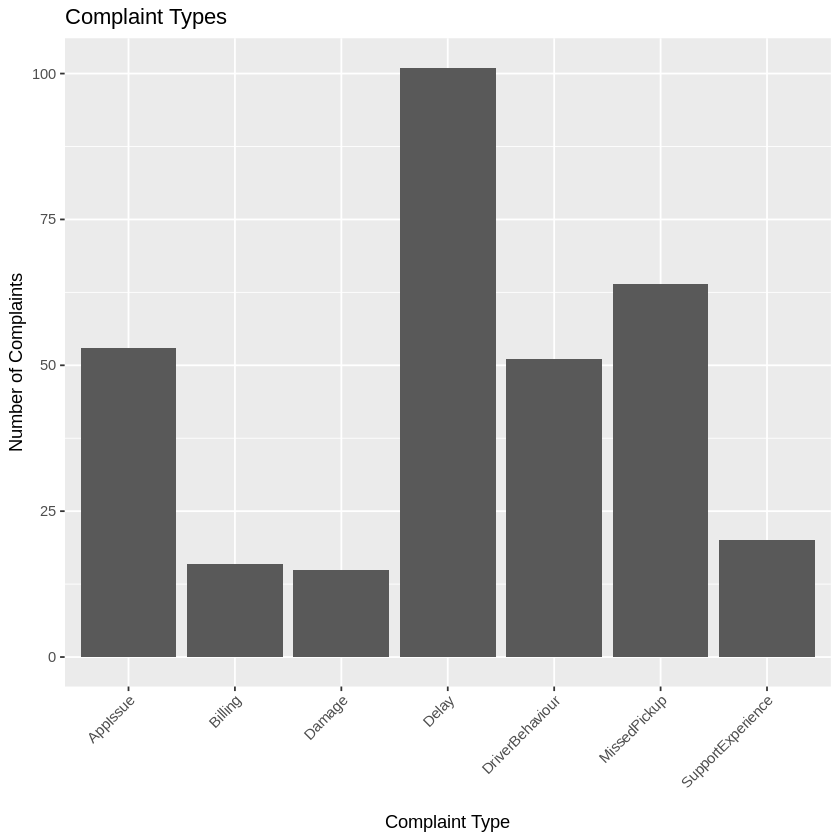

In [11]:
ggplot(complaints, aes(x = complaint_type)) +
  geom_bar() +
  labs(
    title = "Complaint Types",
    x = "Complaint Type",
    y = "Number of Complaints"
  ) +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

Warning message:
“Removed 14 rows containing missing values or values outside the scale range
(`geom_point()`).”


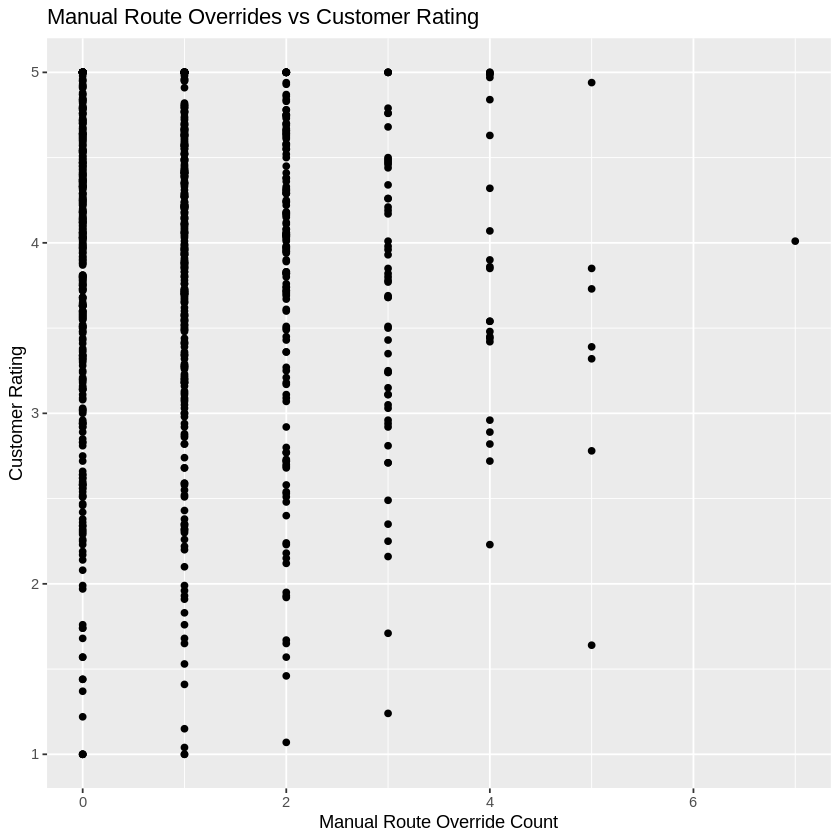

In [12]:
ggplot(deliveries, aes(x = manual_route_override_count, y = customer_rating_post_delivery)) +
  geom_point() +
  labs(
    title = "Manual Route Overrides vs Customer Rating",
    x = "Manual Route Override Count",
    y = "Customer Rating"
  )

Warning message:
“Removed 4 rows containing non-finite outside the scale range
(`stat_boxplot()`).”


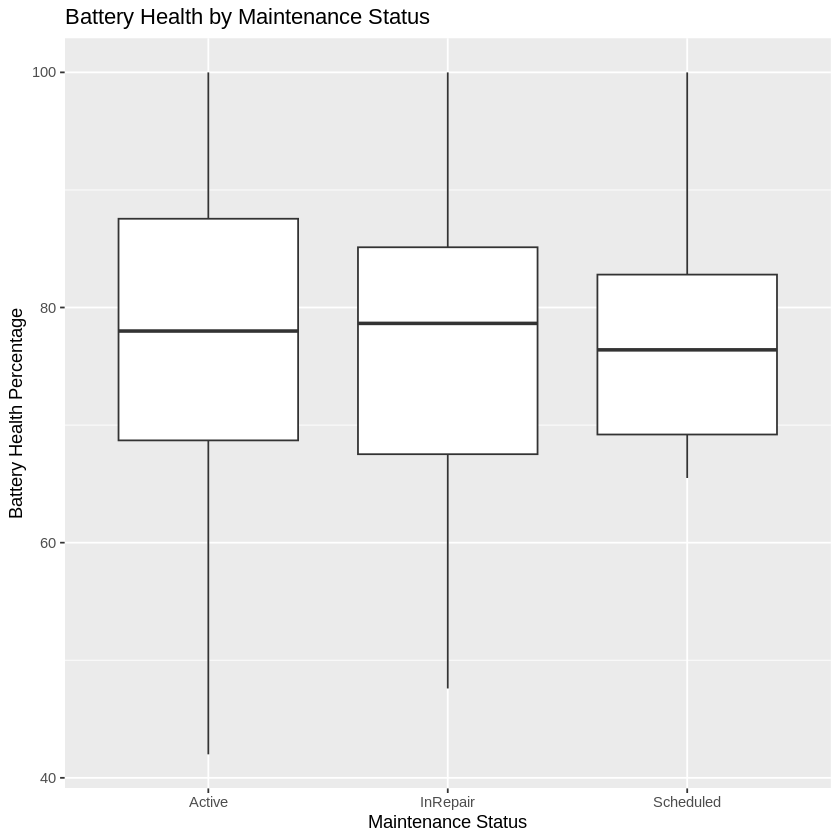

In [13]:
ggplot(vehicles, aes(x = maintenance_status, y = battery_health_pct)) +
  geom_boxplot() +
  labs(
    title = "Battery Health by Maintenance Status",
    x = "Maintenance Status",
    y = "Battery Health Percentage"
  )

In [14]:
summary(deliveries)

    delivery_id       order_id       driver_id       vehicle_id 
 Length   :950   Length   :950   Length   :950   Length   :950  
 N.unique :950   N.unique :950   N.unique :170   N.unique :120  
 N.blank  :  0   N.blank  :  0   N.blank  :  0   N.blank  :  0  
 Min.nchar:  7   Min.nchar:  6   Min.nchar:  4   Min.nchar:  4  
 Max.nchar:  7   Max.nchar:  6   Max.nchar:  4   Max.nchar:  4  
                                                                
                                                                
       hub_id    dispatch_time                 delivery_completed_at        
 Length   :950   Min.   :2024-01-01 03:20:00   Min.   :2024-01-01 15:35:48  
 N.unique :  8   1st Qu.:2024-06-21 17:54:00   1st Qu.:2024-06-18 14:13:03  
 N.blank  :  0   Median :2024-12-12 14:19:30   Median :2024-12-13 02:04:50  
 Min.nchar:  3   Mean   :2024-12-20 13:10:27   Mean   :2024-12-19 20:19:52  
 Max.nchar:  3   3rd Qu.:2025-06-12 01:39:15   3rd Qu.:2025-06-12 00:14:26  
                 M

In [15]:
numeric_data <- deliveries[, c(
  "route_distance_km",
  "manual_route_override_count",
  "fuel_or_charge_cost",
  "customer_rating_post_delivery"
)]

cor(numeric_data, use = "complete.obs")

,route_distance_km,manual_route_override_count,fuel_or_charge_cost,customer_rating_post_delivery
route_distance_km,1.00000000,0.19938470,0.52655156,0.02852525
manual_route_override_count,0.19938470,1.00000000,0.09882420,-0.05990295
fuel_or_charge_cost,0.52655156,0.09882420,1.00000000,-0.05906232
customer_rating_post_delivery,0.02852525,-0.05990295,-0.05906232,1.00000000


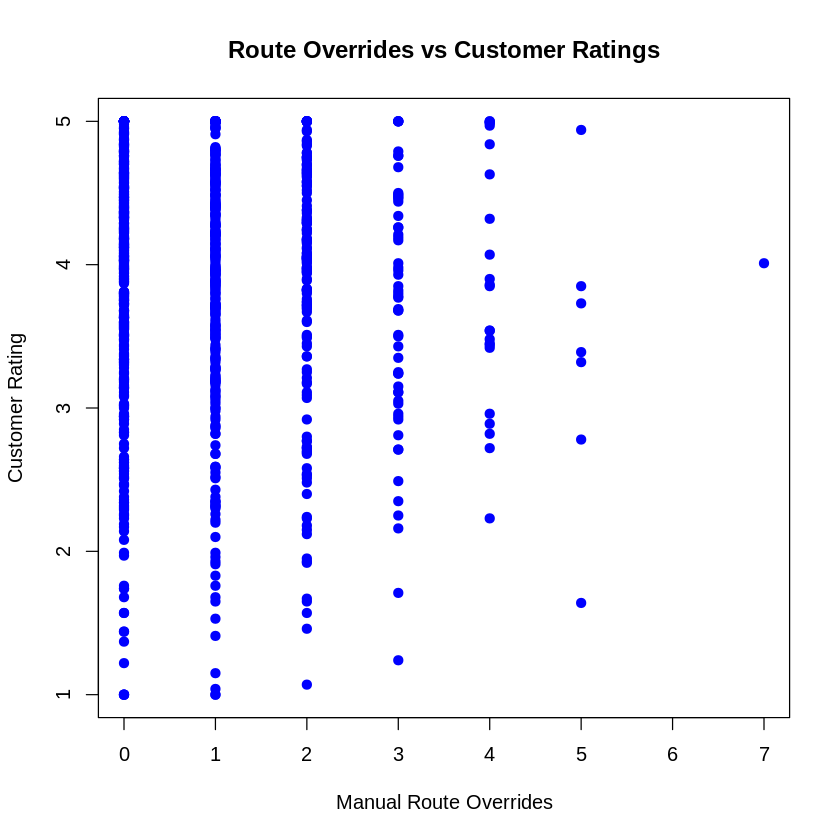

In [16]:
plot(
  deliveries$manual_route_override_count,
  deliveries$customer_rating_post_delivery,
  main = "Route Overrides vs Customer Ratings",
  xlab = "Manual Route Overrides",
  ylab = "Customer Rating",
  col = "blue",
  pch = 19
)

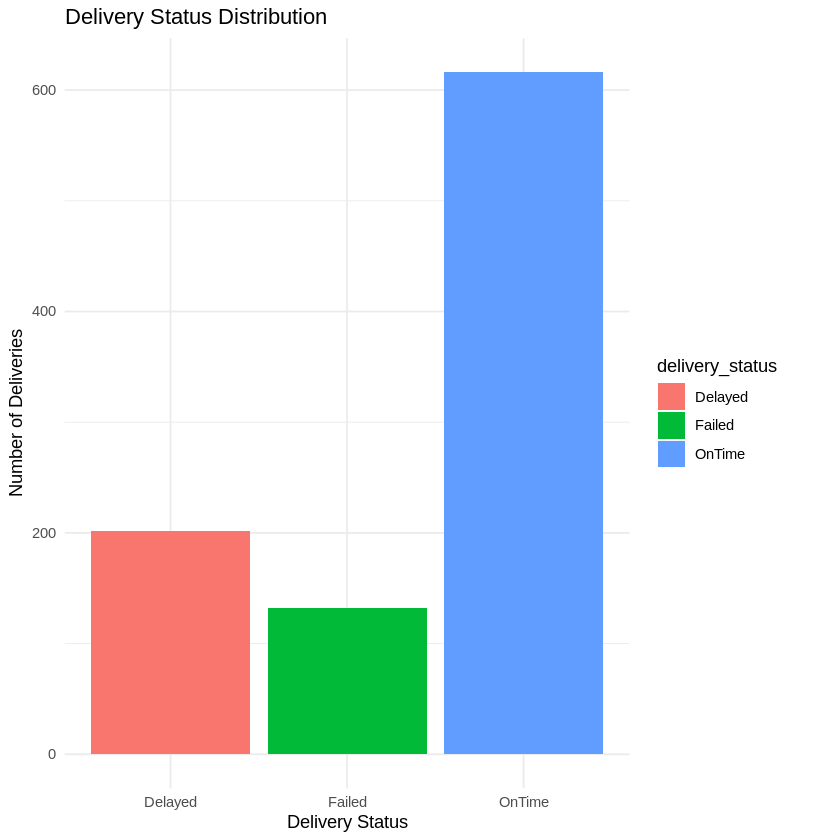

In [18]:
library(ggplot2)

ggplot(deliveries, aes(x = delivery_status, fill = delivery_status)) +
  geom_bar() +
  labs(
    title = "Delivery Status Distribution",
    x = "Delivery Status",
    y = "Number of Deliveries"
  ) +
  theme_minimal()

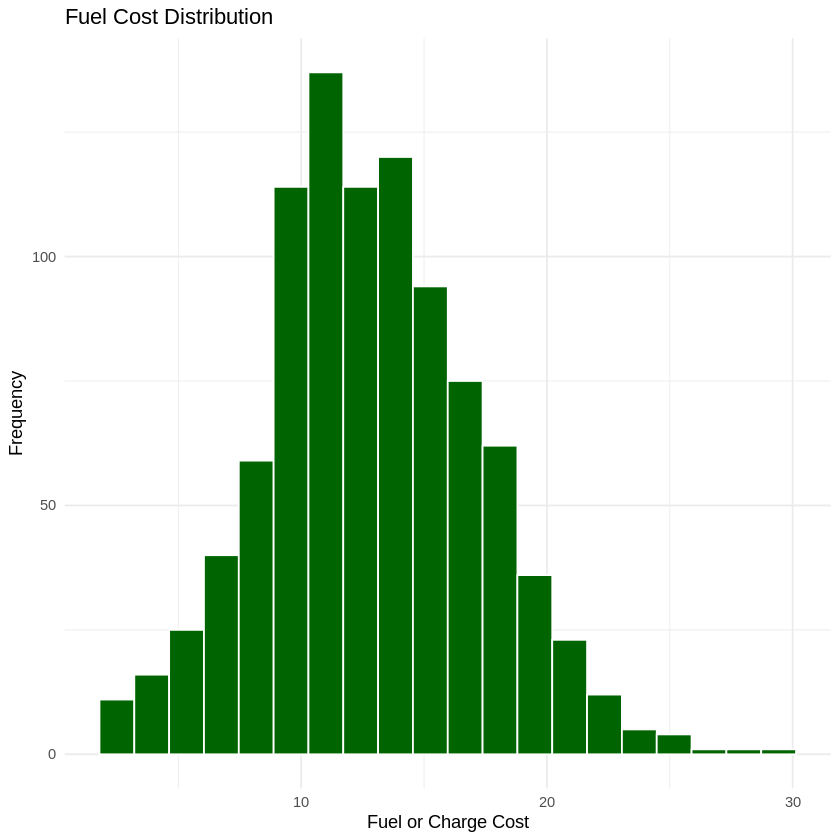

In [19]:
ggplot(deliveries, aes(x = fuel_or_charge_cost)) +
  geom_histogram(bins = 20, fill = "darkgreen", color = "white") +
  labs(
    title = "Fuel Cost Distribution",
    x = "Fuel or Charge Cost",
    y = "Frequency"
  ) +
  theme_minimal()